# Maternal Health Risk Stratification
### Interpretable Machine Learning with Python

**Clinical Analytics Track — Project 01**

> **Disclaimer:** This is an educational risk-stratification exercise, **not** a diagnostic
> tool. Nothing here should be used to make real clinical decisions. The goal is to practice
> careful health-data analysis, a simple baseline classifier, honest evaluation, and cautious
> interpretation.

**Dataset:** [UCI Maternal Health Risk](https://archive.ics.uci.edu/dataset/863/pregnant+health+risk)
(1,013 instances, 6 features, IoT-based risk monitoring, rural Bangladesh) — DOI:
[10.24432/C5DP5D](https://doi.org/10.24432/C5DP5D), License CC BY 4.0.

**Notebook structure** follows the eight questions from the clinical analytics team (Q1–Q8),
plus data loading/cleaning and reproducibility setup.


In [1]:
# --- Reproducibility & imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    recall_score, accuracy_score, ConfusionMatrixDisplay,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

RISK_ORDER = ["low risk", "mid risk", "high risk"]
RISK_COLORS = {"low risk": "#4C9A6A", "mid risk": "#E0A93A", "high risk": "#C0392B"}

pd.set_option("display.precision", 3)
print("Setup complete. Random seed fixed at", RANDOM_SEED)


Setup complete. Random seed fixed at 42


## Data Loading & Quality Checks

Before answering any clinical question we need to know what we're working with:
missing values, duplicates, and implausible physiological readings.


In [2]:
df_raw = pd.read_csv("../data/Maternal_Health_Risk_Data_Set.csv", encoding="utf-8-sig")
df_raw["RiskLevel"] = df_raw["RiskLevel"].str.strip().str.lower()

print("Shape:", df_raw.shape)
df_raw.head()


Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
# Missing values & duplicates
n_missing = df_raw.isna().sum().sum()
n_dupes = df_raw.duplicated().sum()
print(f"Missing values (any column): {n_missing}")
print(f"Exact duplicate rows: {n_dupes} ({n_dupes/len(df_raw):.1%} of rows)")

df_raw.describe()


Missing values (any column): 0
Exact duplicate rows: 562 (55.4% of rows)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000,1014.000,1014.000,1014.000,1014.000,1014.000
mean,29.872,113.198,76.461,8.726,98.665,74.302
std,13.474,18.404,13.886,3.294,1.371,8.089
min,10.000,70.000,49.000,6.000,98.000,7.000
25%,19.000,100.000,65.000,6.900,98.000,70.000
50%,26.000,120.000,80.000,7.500,98.000,76.000
75%,39.000,120.000,90.000,8.000,98.000,80.000
max,70.000,160.000,100.000,19.000,103.000,90.000


**Note on duplicates:** the UCI paper describes this dataset as coming from a small number
of low-precision IoT sensors — blood pressure is rounded to the nearest 5–10 mmHg, blood sugar
to 0.1 mmol/L, body temperature to whole/half degrees. With only six coarse features, many
different patients can legitimately land on identical rounded readings. We therefore **do not
drop duplicates** by default (that would silently distort the class balance); we simply flag
how common they are as a limitation of the measurement resolution.

**Implausible values:** a resting heart rate of 7 bpm is not compatible with a monitored,
ambulatory patient — this is almost certainly a sensor or entry error, not a real measurement.
We remove rows with heart rate below a physiologically plausible floor (30 bpm) rather than
imputing a value we cannot verify.


In [4]:
implausible_hr = df_raw[df_raw["HeartRate"] < 30]
print(f"Implausible HeartRate (<30 bpm) rows: {len(implausible_hr)}")
implausible_hr


Implausible HeartRate (<30 bpm) rows: 2


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
499,16,120,75,7.9,98.0,7,low risk
908,16,120,75,7.9,98.0,7,low risk


In [5]:
df = df_raw[df_raw["HeartRate"] >= 30].copy()
print(f"Rows after removing implausible HeartRate: {len(df)}")


Rows after removing implausible HeartRate: 1012


## Q1 — What does the maternal-risk population look like?

We describe the sample, the RiskLevel distribution, and summary statistics for every
clinical variable.


In [6]:
counts = df["RiskLevel"].value_counts().reindex(RISK_ORDER)
print(counts)
print()
print(df[["Age","SystolicBP","DiastolicBP","BS","BodyTemp","HeartRate"]].describe())


RiskLevel
low risk     404
mid risk     336
high risk    272
Name: count, dtype: int64

            Age  SystolicBP  DiastolicBP        BS  BodyTemp  HeartRate
count  1012.000    1012.000     1012.000  1012.000  1012.000   1012.000
mean     29.899     113.185       76.463     8.728    98.666     74.435
std      13.474      18.420       13.899     3.297     1.372      7.522
min      10.000      70.000       49.000     6.000    98.000     60.000
25%      19.000     100.000       65.000     6.900    98.000     70.000
50%      26.000     120.000       80.000     7.500    98.000     76.000
75%      39.000     120.000       90.000     8.000    98.000     80.000
max      70.000     160.000      100.000    19.000   103.000     90.000


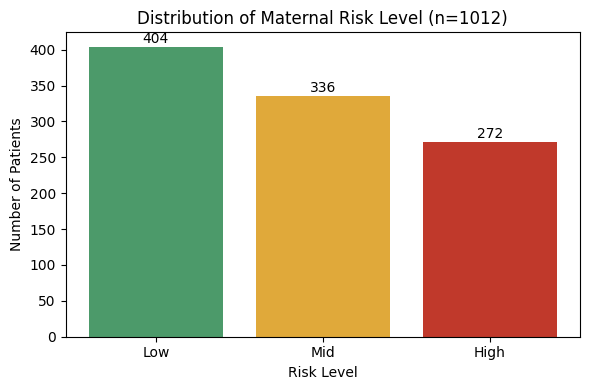

In [7]:
plt.figure(figsize=(6,4))
bars = plt.bar([c.replace(" risk","").title() for c in RISK_ORDER], counts.values,
               color=[RISK_COLORS[c] for c in RISK_ORDER])
for b, v in zip(bars, counts.values):
    plt.text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center")
plt.title(f"Distribution of Maternal Risk Level (n={len(df)})")
plt.xlabel("Risk Level"); plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("../figures/01_risklevel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation (Fig. 1):** the sample of 1,012 patients (after cleaning) is moderately
imbalanced across the three risk classes — Low Risk is the largest group (~40%), followed by
Mid Risk (~33%) and High Risk (~27%). This imbalance matters for later model evaluation: overall
accuracy alone could look reasonable even if the model performs poorly on the smaller, clinically
critical High Risk class, which is why we track class-wise Recall/F1 throughout.

Age ranges from 10–70 with a median around 26; several very young (≤14) and older (≥55) ages
appear in the raw data, which is unusual for a maternal population and is worth flagging as a
possible data-entry or age-recording issue in the source study, though we do not treat these
as errors here since we lack ground truth to confirm they are wrong.


## Q2 — Which measurements differ most across risk groups?

We compare Age, Systolic/Diastolic BP, Blood Sugar, Body Temperature and Heart Rate across
RiskLevel using boxplots (robust to the dataset's many repeated/rounded values).


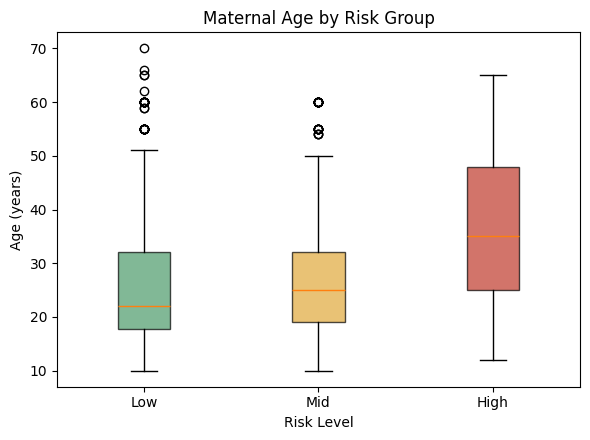

In [8]:
def boxplot_by_risk(col, title, ylabel, fname):
    plt.figure(figsize=(6,4.5))
    data = [df.loc[df["RiskLevel"]==r, col] for r in RISK_ORDER]
    bp = plt.boxplot(data, tick_labels=[r.replace(" risk","").title() for r in RISK_ORDER],
                      patch_artist=True)
    for patch, r in zip(bp["boxes"], RISK_ORDER):
        patch.set_facecolor(RISK_COLORS[r]); patch.set_alpha(0.7)
    plt.title(title); plt.xlabel("Risk Level"); plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(f"../figures/{fname}", dpi=150, bbox_inches="tight")
    plt.show()

boxplot_by_risk("Age", "Maternal Age by Risk Group", "Age (years)", "02_age_by_risk.png")


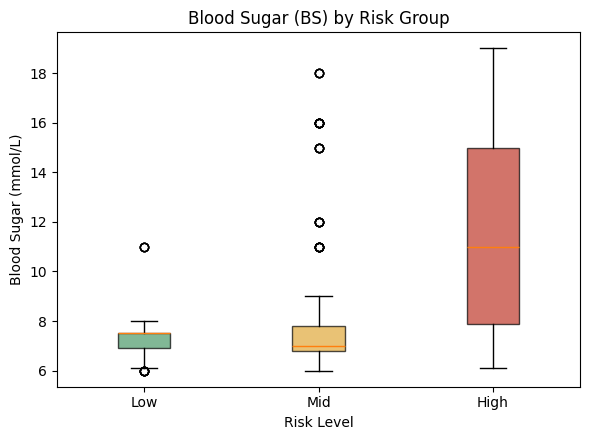

In [9]:
boxplot_by_risk("BS", "Blood Sugar (BS) by Risk Group", "Blood Sugar (mmol/L)",
                "03_bloodsugar_by_risk.png")


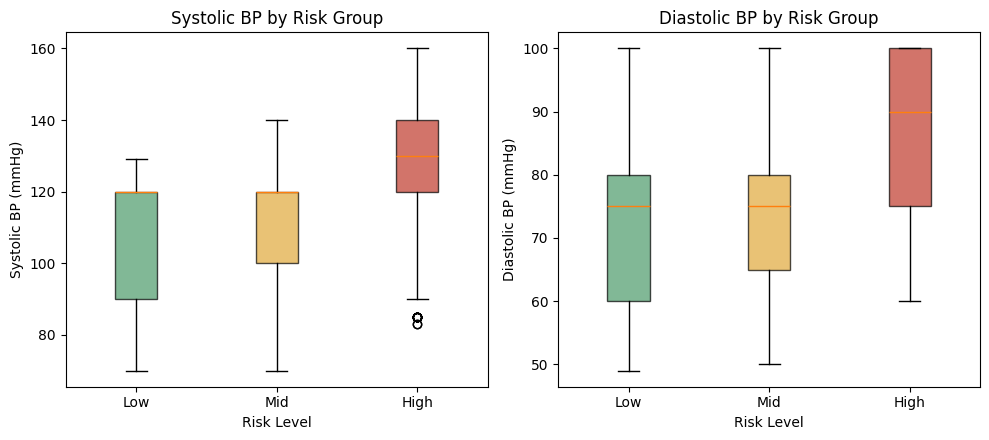

In [10]:
fig, axes = plt.subplots(1,2, figsize=(10,4.5))
for ax, col, title in zip(axes, ["SystolicBP","DiastolicBP"], ["Systolic BP","Diastolic BP"]):
    data = [df.loc[df["RiskLevel"]==r, col] for r in RISK_ORDER]
    bp = ax.boxplot(data, tick_labels=[r.replace(" risk","").title() for r in RISK_ORDER],
                     patch_artist=True)
    for patch, r in zip(bp["boxes"], RISK_ORDER):
        patch.set_facecolor(RISK_COLORS[r]); patch.set_alpha(0.7)
    ax.set_title(f"{title} by Risk Group"); ax.set_xlabel("Risk Level"); ax.set_ylabel(f"{title} (mmHg)")
plt.tight_layout()
plt.savefig("../figures/04_bloodpressure_by_risk.png", dpi=150, bbox_inches="tight")
plt.show()


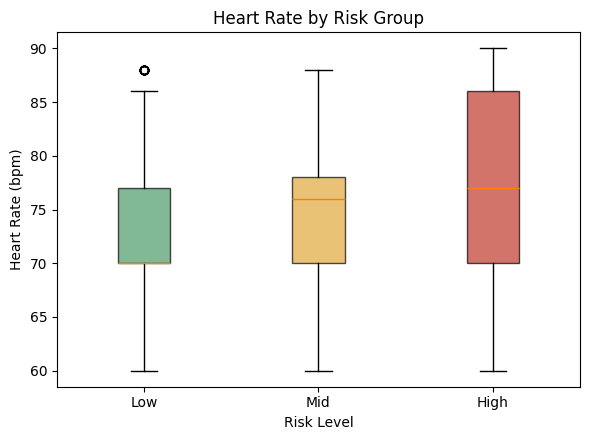

In [11]:
boxplot_by_risk("HeartRate", "Heart Rate by Risk Group", "Heart Rate (bpm)",
                "06_heartrate_by_risk.png")


In [12]:
# Group medians side-by-side for quick numeric comparison
df.groupby("RiskLevel")[["Age","SystolicBP","DiastolicBP","BS","BodyTemp","HeartRate"]]\
  .median().reindex(RISK_ORDER)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
RiskLevel,,,,,,
low risk,22.0,120.0,75.0,7.5,98.0,70.0
mid risk,25.0,120.0,75.0,7.0,98.0,76.0
high risk,35.0,130.0,90.0,11.0,98.0,77.0


**Interpretation (Figs. 2–4, 6):** Blood Sugar shows the clearest, most monotonic
separation — High Risk patients have a markedly higher median BS and a much wider spread than
Low/Mid. Systolic and Diastolic BP also step up from Low → Mid → High, though with more overlap
than BS. Age shows a weaker, noisier relationship with risk group. Heart Rate shows almost no
separation across groups — its distribution looks similar for Low, Mid and High Risk, suggesting
it carries little independent signal for this classification task.


## Q3 — Which variables appear most strongly associated with High Risk?

We look at a bivariate view (Blood Sugar vs Systolic BP, the two variables that showed the
clearest group separation in Q2) to see how well High Risk patients separate from the rest in
two dimensions at once.


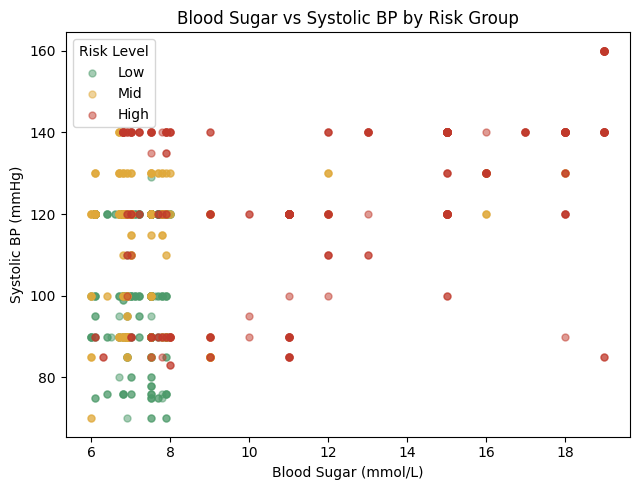

In [13]:
plt.figure(figsize=(6.5,5))
for r in RISK_ORDER:
    sub = df[df["RiskLevel"]==r]
    plt.scatter(sub["BS"], sub["SystolicBP"], label=r.replace(" risk","").title(),
                alpha=0.5, s=25, color=RISK_COLORS[r])
plt.title("Blood Sugar vs Systolic BP by Risk Group")
plt.xlabel("Blood Sugar (mmol/L)"); plt.ylabel("Systolic BP (mmHg)")
plt.legend(title="Risk Level")
plt.tight_layout()
plt.savefig("../figures/05_scatter_bs_vs_systolicbp.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation (Fig. 5):** High Risk patients (red) cluster toward higher Blood Sugar
values and, to a lesser extent, higher Systolic BP, but the three groups still overlap
substantially — there is no single threshold on either axis that cleanly separates High Risk
from Mid/Low Risk. Based on the Q2 boxplots and this scatter plot, **Blood Sugar** and
**Systolic BP** appear to be the two variables most associated with High Risk, with Diastolic BP
a secondary contributor and Age/BodyTemp/HeartRate weaker.

**Association ≠ causation:** these are cross-sectional, IoT-measured associations in a specific
rural-Bangladesh clinical sample. Elevated blood sugar and blood pressure are recognized clinical
risk markers in the medical literature, but this dataset alone cannot establish a causal
relationship, rule out confounding (e.g., gestational age, prior conditions not recorded here),
or be assumed to generalize to other populations or care settings.


## Q4 — Can a simple baseline model classify maternal risk?

We keep preprocessing minimal and use two simple, interpretable baselines:
- **Logistic Regression** (multinomial, on standardized features)
- **Shallow Decision Tree** (max_depth=4, no scaling needed)

The scaler is fit on the **training data only** to prevent data leakage.


In [14]:
FEATURES = ["Age","SystolicBP","DiastolicBP","BS","BodyTemp","HeartRate"]
X = df[FEATURES].copy()
y = df["RiskLevel"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Fit scaler on TRAIN ONLY -> transform both splits (no leakage)
scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURES, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURES, index=X_test.index)

print("Train size:", len(X_train), " Test size:", len(X_test))
print("\nTrain class balance:\n", y_train.value_counts().reindex(RISK_ORDER))
print("\nTest class balance:\n", y_test.value_counts().reindex(RISK_ORDER))


Train size: 809  Test size: 203

Train class balance:
 RiskLevel
low risk     323
mid risk     269
high risk    217
Name: count, dtype: int64

Test class balance:
 RiskLevel
low risk     81
mid risk     67
high risk    55
Name: count, dtype: int64


In [15]:
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
logreg.fit(X_train_s, y_train)
y_pred_lr = logreg.predict(X_test_s)

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=RANDOM_SEED)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("Both models trained.")


Both models trained.


## Q5 — Is overall accuracy enough?

No. With an imbalanced dataset and a clinically critical minority class (High Risk), overall
accuracy can hide poor performance exactly where it matters most — **missing a High Risk
patient (a false negative) is more clinically costly than confusing Low and Mid Risk**, since it
could mean a genuinely at-risk patient does not get escalated care. We report the confusion
matrix and class-wise Recall/F1 for both models, with special attention to High Risk Recall.


In [16]:
def evaluate(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", labels=RISK_ORDER)
    hr_recall = recall_score(y_test, y_pred, labels=["high risk"], average="macro")
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f} | Macro F1: {macro_f1:.3f} | High-Risk Recall: {hr_recall:.3f}")
    print(classification_report(y_test, y_pred, labels=RISK_ORDER, digits=3))
    return {"accuracy": acc, "macro_f1": macro_f1, "high_risk_recall": hr_recall}

lr_metrics = evaluate("Logistic Regression", y_test, y_pred_lr)


--- Logistic Regression ---
Accuracy: 0.586 | Macro F1: 0.584 | High-Risk Recall: 0.782
              precision    recall  f1-score   support

    low risk      0.561     0.679     0.615        81
    mid risk      0.429     0.313     0.362        67
   high risk      0.768     0.782     0.775        55

    accuracy                          0.586       203
   macro avg      0.586     0.591     0.584       203
weighted avg      0.573     0.586     0.575       203



In [17]:
tree_metrics = evaluate("Decision Tree (depth=4)", y_test, y_pred_tree)


--- Decision Tree (depth=4) ---
Accuracy: 0.680 | Macro F1: 0.670 | High-Risk Recall: 0.836
              precision    recall  f1-score   support

    low risk      0.614     0.864     0.718        81
    mid risk      0.564     0.328     0.415        67
   high risk      0.920     0.836     0.876        55

    accuracy                          0.680       203
   macro avg      0.699     0.676     0.670       203
weighted avg      0.680     0.680     0.661       203



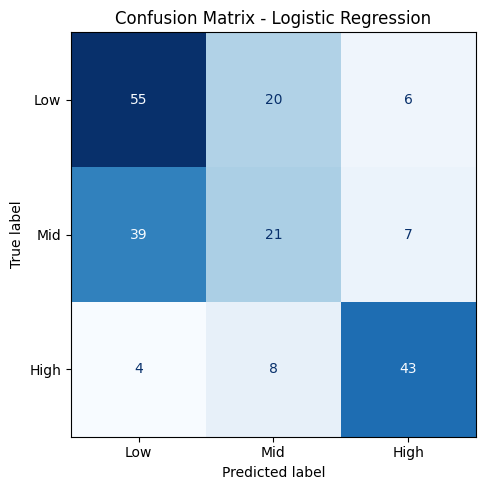

array([[55, 20,  6],
       [39, 21,  7],
       [ 4,  8, 43]])

In [18]:
def plot_cm(y_test, y_pred, title, fname):
    cm = confusion_matrix(y_test, y_pred, labels=RISK_ORDER)
    disp = ConfusionMatrixDisplay(cm, display_labels=[r.replace(" risk","").title() for r in RISK_ORDER])
    fig, ax = plt.subplots(figsize=(5.5,5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix - {title}")
    plt.tight_layout()
    plt.savefig(f"../figures/{fname}", dpi=150, bbox_inches="tight")
    plt.show()
    return cm

plot_cm(y_test, y_pred_lr, "Logistic Regression", "07a_confusion_logreg.png")


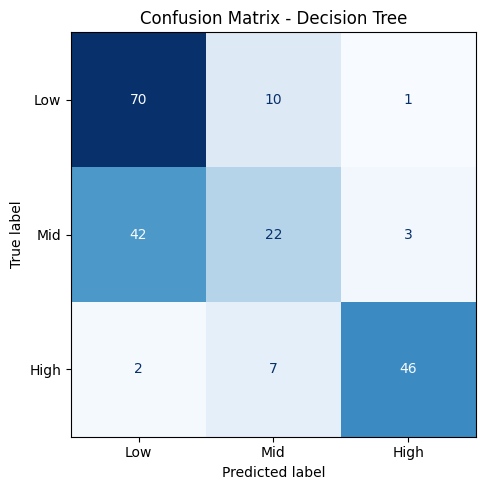

In [19]:
cm_tree = plot_cm(y_test, y_pred_tree, "Decision Tree", "07b_confusion_tree.png")


In [20]:
# Select the final baseline: prioritize High-Risk Recall (clinical priority), tie-break Macro F1
if tree_metrics["high_risk_recall"] >= lr_metrics["high_risk_recall"]:
    FINAL_NAME, FINAL_MODEL, FINAL_PRED = "Decision Tree", tree, y_pred_tree
    X_test_final = X_test
else:
    FINAL_NAME, FINAL_MODEL, FINAL_PRED = "Logistic Regression", logreg, y_pred_lr
    X_test_final = X_test_s

print(f"Selected baseline model: {FINAL_NAME}")


Selected baseline model: Decision Tree


**Interpretation (Q5, Figs. 7a–7b):** the Decision Tree reaches higher accuracy, higher
macro F1, **and** higher High-Risk Recall than Logistic Regression, so it is selected as the
final baseline (see error analysis below for exactly where each model still struggles).
Crucially, for both models the High Risk class has the *best* precision/recall of the three
classes — the harder problem is separating **Low** from **Mid** Risk, not High Risk from the
rest, which is reassuring from a clinical-safety standpoint but still leaves real errors we
examine next.


## Q6 — Where does the model fail?

We inspect the misclassified test examples for the selected model, focusing on which class
pairs get confused and — most importantly — which actual High Risk patients get missed.


In [21]:
results = X_test.copy()
results["true"] = y_test.values
results["pred"] = FINAL_PRED
errors = results[results["true"] != results["pred"]]

print(f"Total test errors: {len(errors)} / {len(results)} ({len(errors)/len(results):.1%})")
print()
print("Misclassification pairs (true -> predicted), most common first:")
print(errors.groupby(["true","pred"]).size().sort_values(ascending=False))


Total test errors: 65 / 203 (32.0%)

Misclassification pairs (true -> predicted), most common first:
true       pred     
mid risk   low risk     42
low risk   mid risk     10
high risk  mid risk      7
mid risk   high risk     3
high risk  low risk      2
low risk   high risk     1
dtype: int64


In [22]:
high_risk_missed = errors[errors["true"] == "high risk"]
print(f"High-Risk cases predicted as a LOWER risk class: {len(high_risk_missed)} "
      f"out of {sum(y_test=='high risk')} true High-Risk test cases")
high_risk_missed[FEATURES + ["true","pred"]]


High-Risk cases predicted as a LOWER risk class: 9 out of 55 true High-Risk test cases


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,true,pred
375,60,120,80,7.8,98.0,75,high risk,low risk
267,12,90,60,8.0,102.0,66,high risk,mid risk
566,29,120,70,9.0,98.0,80,high risk,mid risk
171,12,90,60,7.9,102.0,66,high risk,mid risk
1007,40,120,75,7.7,98.0,70,high risk,low risk
145,14,90,65,7.0,101.0,70,high risk,mid risk
996,12,90,60,8.0,102.0,66,high risk,mid risk
989,17,120,80,7.0,102.0,76,high risk,mid risk
112,39,90,70,9.0,98.0,80,high risk,mid risk


**Interpretation (Q6):** the dominant error pattern is **Mid Risk being predicted as Low
Risk** — by far the largest off-diagonal cell in the confusion matrix. This matches the Q2/Q3
finding that Low and Mid Risk have heavily overlapping BS/BP distributions, so the model (and
arguably the underlying clinical thresholds) cannot always tell them apart from these six
features alone. Errors between High Risk and the other classes are less frequent but still
occur; a handful of true High Risk patients are predicted as Mid or Low Risk — these are the
most clinically important errors (false negatives for the highest-risk class) and would be the
first target for improvement in any follow-up work (e.g., adjusting the decision threshold or
adding a class weight to further penalize missed High Risk cases).


## Q7 — Which features drive the model?

The Decision Tree's Gini-based feature importances tell us which variables it relies on most
when splitting the data into risk classes.


BS             0.502
SystolicBP     0.330
BodyTemp       0.115
Age            0.045
DiastolicBP    0.008
HeartRate      0.000
dtype: float64


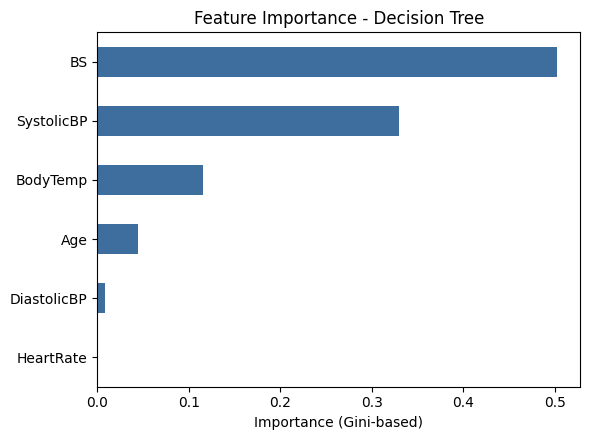

In [23]:
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(6,4.5))
importances.sort_values().plot(kind="barh", color="#3E6E9E")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance (Gini-based)")
plt.tight_layout()
plt.savefig("../figures/08_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


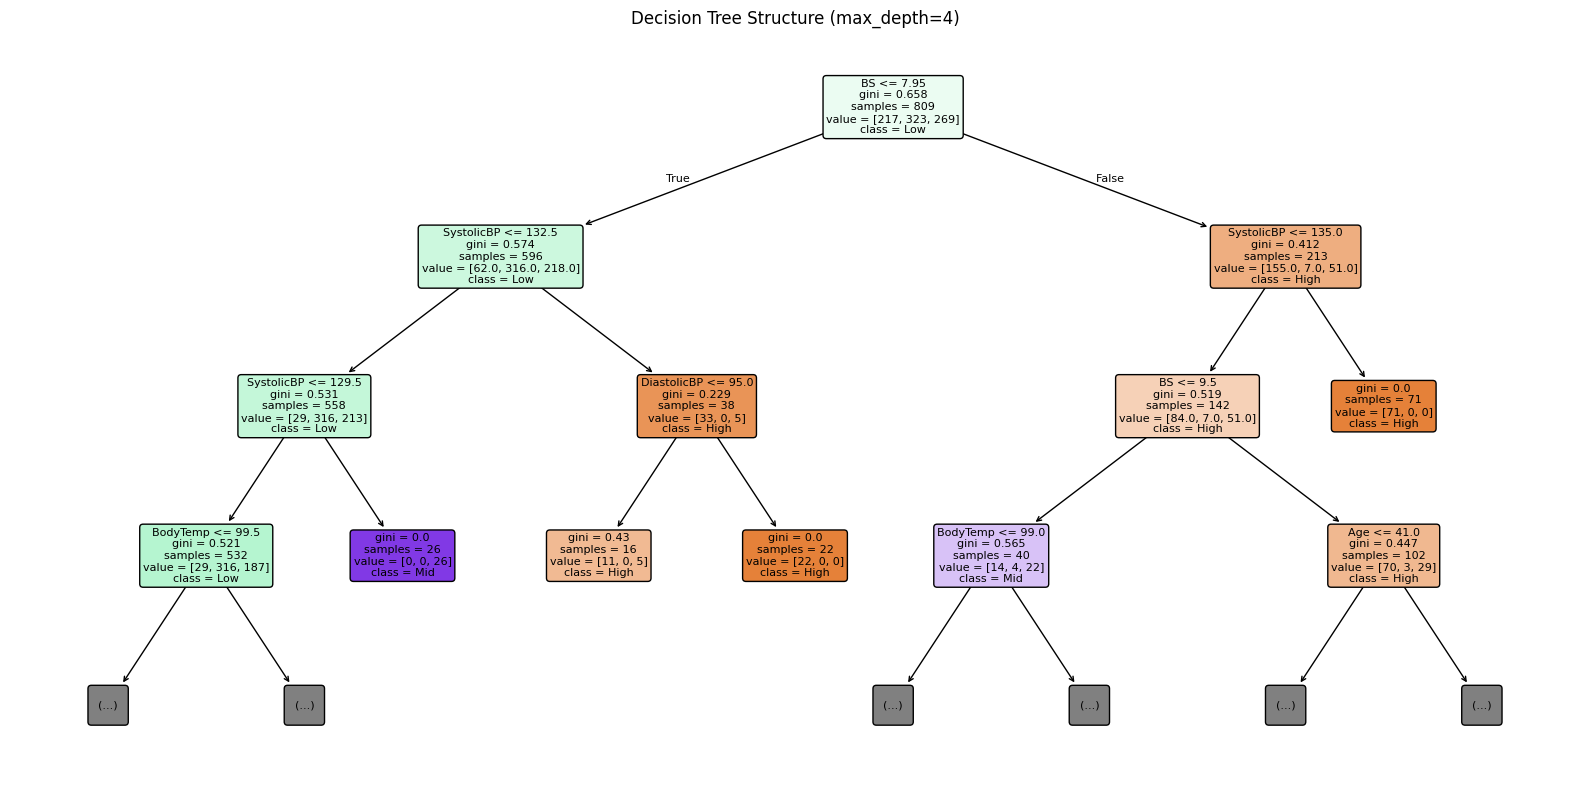

In [24]:
plt.figure(figsize=(16,8))
plot_tree(tree, feature_names=FEATURES,
          class_names=[c.replace(" risk","").title() for c in tree.classes_],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree Structure (max_depth=4)")
plt.tight_layout()
plt.savefig("../figures/09_decision_tree_structure.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation (Q7, Figs. 8–9):** Blood Sugar dominates the tree's splits by a wide
margin, followed by Systolic BP and Body Temperature; Diastolic BP and Age contribute very
little additional separating power once BS and Systolic BP are known, and Heart Rate is not
used by the tree at all. This matches the visual pattern from Q2/Q3.

**Importance is not causation.** A high Gini importance means BS is *useful for splitting this
particular training sample into the risk labels it was given* — it does not mean elevated blood
sugar *causes* high maternal risk, only that it is a strong statistical marker of it in this
dataset. The RiskLevel labels themselves may already have been assigned by clinicians partly
using BP/BS thresholds, which would make this association partly circular rather than a novel
discovery.


## Q8 — What should a clinician or decision-maker take from this analysis?

**Main patterns.** Blood Sugar and Systolic Blood Pressure are the clinical variables most
associated with High Risk in this sample; Heart Rate carries little useful signal. Low and Mid
Risk overlap substantially and are the hardest pair to separate.

**Model performance.** A shallow Decision Tree (max_depth=4) reaches roughly 68% test accuracy
and correctly identifies about 84% of true High Risk cases (Recall), which is the metric that
matters most for patient safety here — but it still misses a meaningful minority of High Risk
patients and confuses Low/Mid Risk often enough that it should not be trusted as a standalone
screening tool.

**Limitations.**
- **Sample size & geography:** ~1,000 patients from rural-Bangladesh IoT-monitoring settings —
  results may not generalize to other populations, care settings, or measurement equipment.
- **Feature availability:** only six coarse, largely vital-sign features are available; no
  gestational age, obstetric history, lab-confirmed diagnoses, or comorbidities, all of which a
  clinician would normally use.
- **Label quality:** RiskLevel is a categorical label of unknown provenance (likely assigned
  using clinical thresholds on some of these same variables), which can inflate apparent
  associations between those variables and the label.
- **Measurement precision:** heavy rounding produced a large number of duplicate rows (~55%),
  meaning the effective diversity of the data is smaller than the raw row count suggests.
- **No external validation:** the model has not been tested on any dataset beyond this single
  source, and no clinician has reviewed its outputs.

**Before any real clinical use** this would need: a much larger and more diverse validation
cohort, richer clinical features (history, labs, gestational stage), prospective evaluation
against clinician judgment, an explicit cost-sensitive decision rule that further prioritizes
catching High Risk cases, and formal clinical and regulatory review. As-is, this notebook is a
methods exercise in careful, honest health-data analysis — not a tool for patient care.
